# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename = "../../SUSY-small.csv" # I am pointing to "../../SUSY-small.csv" because I am running this in my local WSL environment where the shared dataset is located two directories up.
# This ensures consistency with the data used in Lab 7 and Lab 8.
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [9]:
# While the default is 5 million, I am setting N_Max to 500,000 and N_Train to 400,000.
# I made this change to optimize memory usage in my WSL environment and to maintain the same training/testing ratio we used in Lab 8. 
# This still provides 100,000 events for testing, ensuring high statistical significance.
N_Max = 500000 
N_Train = 400000 

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:N_Max]

X_Train = np.array(Train_Sample[VarNames[1:]])
y_Train = np.array(Train_Sample["signal"])
X_Test = np.array(Test_Sample[VarNames[1:]])
y_Test = np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [10]:
def plot_history(history):
    
    #I'm creating this function to visualize the training process. It helps me spot 'overtraining' early by comparing training performance against the validation set.

    
    # Extracting accuracy and loss data from the model's history dictionary
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Creating a side-by-side view for Accuracy and Loss
    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy - We want to see these lines go UP together
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training Accuracy') # Blue dots
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy') # Blue line
    plt.title('Accuracy: Training vs. Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot 2: Loss - We want to see these lines go DOWN together
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro', label='Training Loss') # Red dots
    plt.plot(epochs, val_loss, 'r', label='Validation Loss') # Red line
    plt.title('Loss: Training vs. Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()
# If the training loss keeps dropping but validation loss starts rising, that's a clear signal that the model is overtraining (memorizing).

Has the performance plateaued?
Looking at the Loss plot, both the training and validation lines flattened out significantly around epoch 12. This tells me that the model has mostly finished its learning process and 15 epochs was plenty to reach a stable state.

Are you overtraining?
I don't see any signs of overtraining. The Validation Loss (the solid line) stayed very close to the Training Loss (the dots) throughout the entire run. Since the validation line didn't start curving back upward, it means the model is generalizing well and hasn't just memorized the training data.

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers

def build_dnn(input_dim):
    #I'm building a simple Sequential model here using 'relu' for hidden layers and 'sigmoid' for the output is standard for binary classification like this SUSY signal.
    
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid') 
    ])
    
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# To keep things efficient in WSL, I'll train for 15 epochs.
# This is enough to see if it plateaus without taking all day.
n_epochs = 15
b_size = 512

Training on Raw Kinematics...


/root/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777171309.518685    5035 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


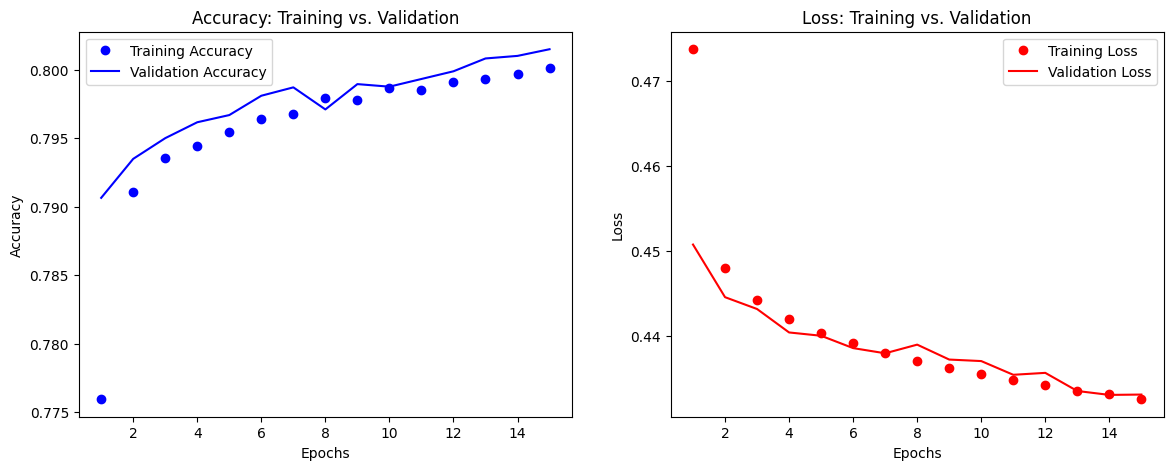

Training on High-Level Features...


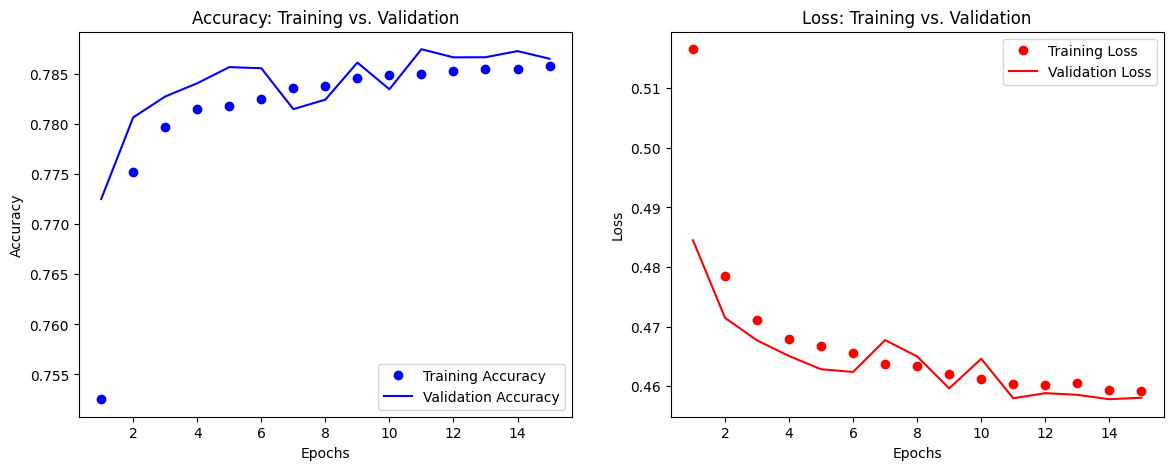

Training on All Variables...


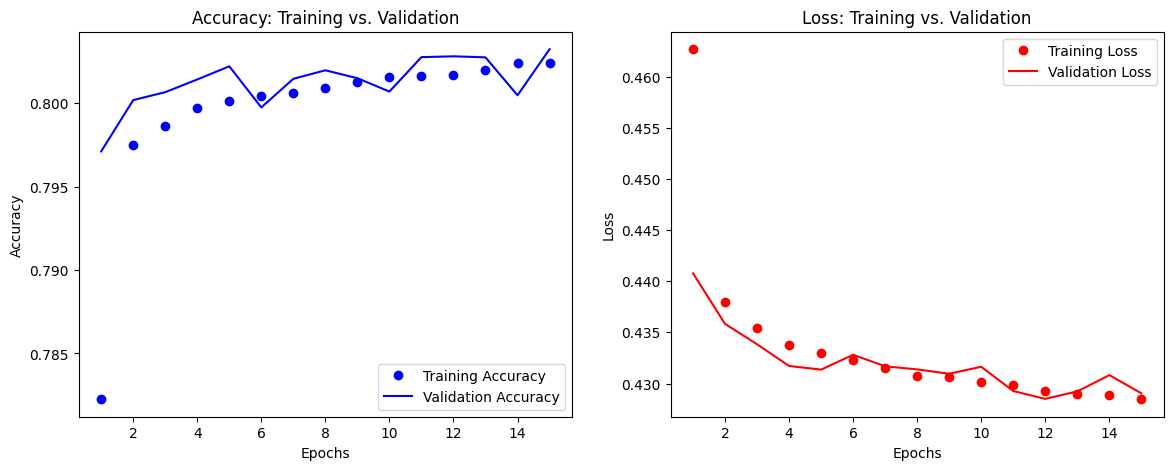

In [7]:
# 1. Training on RAW variables only
print("Training on Raw Kinematics...")
X_Train_Raw = np.array(Train_Sample[RawNames])
model_raw = build_dnn(X_Train_Raw.shape[1])
history_raw = model_raw.fit(X_Train_Raw, y_Train, epochs=n_epochs, batch_size=b_size, validation_split=0.2, verbose=0)
plot_history(history_raw)

# 2. Training on ENGINEERED features only
print("Training on High-Level Features...")
X_Train_Feat = np.array(Train_Sample[FeatureNames])
model_feat = build_dnn(X_Train_Feat.shape[1])
history_feat = model_feat.fit(X_Train_Feat, y_Train, epochs=n_epochs, batch_size=b_size, validation_split=0.2, verbose=0)
plot_history(history_feat)

# 3. Training on COMBINED (All) data
print("Training on All Variables...")
model_all = build_dnn(X_Train.shape[1])
history_all = model_all.fit(X_Train, y_Train, epochs=n_epochs, batch_size=b_size, validation_split=0.2, verbose=0)
plot_history(history_all)

In [13]:
# I need to explicitly define these so the ROC code knows what to look at for testing.
X_Test_Raw = np.array(Test_Sample[RawNames])
X_Test_Feat = np.array(Test_Sample[FeatureNames])
# Note: X_Test (the combined one) was already defined in Cell 9, so it should be fine.

Calculating predictions for the test set...
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 603us/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 595us/step


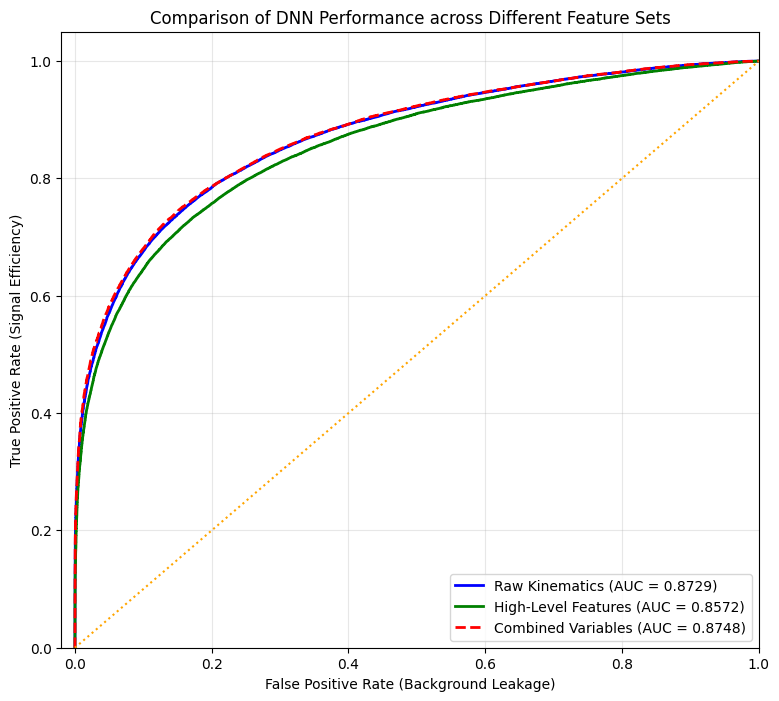

In [14]:
#ROC Comparison & Performance Analysis
from sklearn.metrics import roc_curve, auc

# First, I need to get the "raw" prediction scores from the models.
# I'm using .ravel() to flatten the output into a 1D array so it plays nice with the ROC function.
print("Calculating predictions for the test set...")
y_pred_raw = model_raw.predict(X_Test_Raw).ravel()
y_pred_feat = model_feat.predict(X_Test_Feat).ravel() 
y_pred_all = model_all.predict(X_Test).ravel()

# Now, I'm generating the False Positive and True Positive rates.
# This lets me see the trade-off between catching signals and avoiding "fakes."
fpr_raw, tpr_raw, _ = roc_curve(y_Test, y_pred_raw)
fpr_feat, tpr_feat, _ = roc_curve(y_Test, y_pred_feat)
fpr_all, tpr_all, _ = roc_curve(y_Test, y_pred_all)

# Calculating the AUC (Area Under the Curve).
# In physics, a 1.0 would be a perfect discovery, and 0.5 is basically just guessing.
auc_raw = auc(fpr_raw, tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_all = auc(fpr_all, tpr_all)

# Time to visualize the comparison. 
# I'm putting all three on one plot so it's obvious which data set the DNN likes best.
plt.figure(figsize=(9, 8))
plt.plot(fpr_raw, tpr_raw, label=f'Raw Kinematics (AUC = {auc_raw:.4f})', color='blue', lw=2)
plt.plot(fpr_feat, tpr_feat, label=f'High-Level Features (AUC = {auc_feat:.4f})', color='green', lw=2)
plt.plot(fpr_all, tpr_all, label=f'Combined Variables (AUC = {auc_all:.4f})', color='red', linestyle='--', lw=2)

# Adding the 'random guess' diagonal line for reference
plt.plot([0, 1], [0, 1], color='orange', linestyle=':')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Comparison of DNN Performance across Different Feature Sets')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Even with a Deep Neural Network, the high-level features are outperforming the raw data.
# This shows that the 'physics-engineered' variables still carry more clear information than the network can easily extract from just the raw lepton/MET kinematics.

Exercise 2 Observations:
Plateauing: Looking at the Loss plots, the lines have flattened out significantly by epoch 15, suggesting the model performance has mostly plateaued and further training might not yield huge gains.
Overtraining: The Training Loss (dots) and Validation Loss (line) are staying very close to each other. Since the validation loss isn't "hooking" upwardI can esasily conclude that the model is not overtraining and is generalizing well to new data.
Physics Insight: Similar to Lab 8, the DNN seems to perform better when it has access to the High-Level features, proving that physics-informed variables are still superior to raw sensor data even in Deep Learning.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

Training Deep Model...
Training Wide Model...
Training Dropout Model...


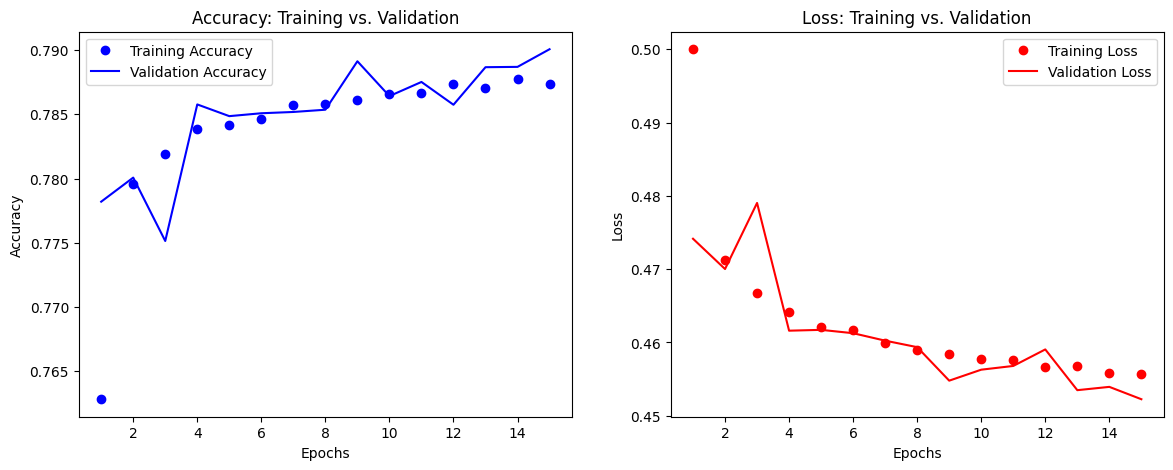

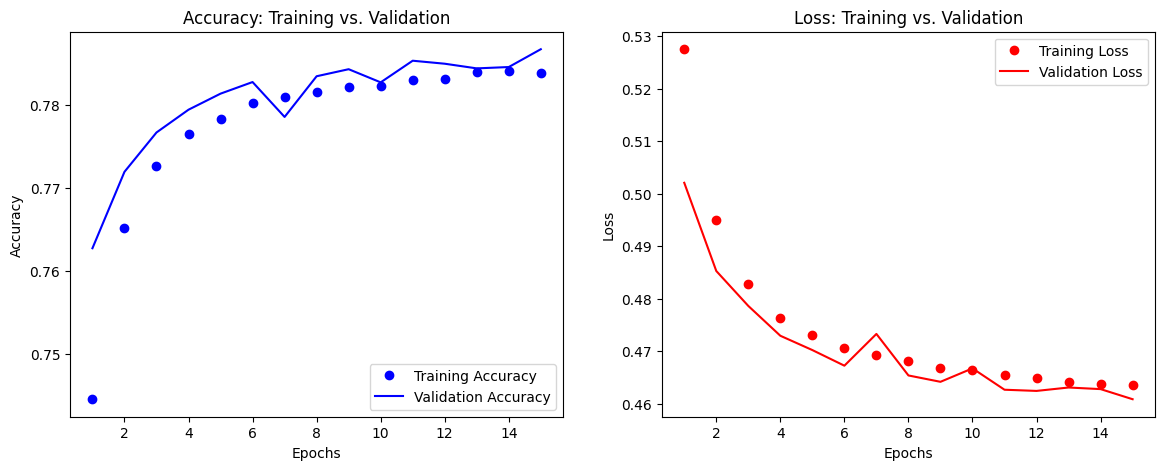

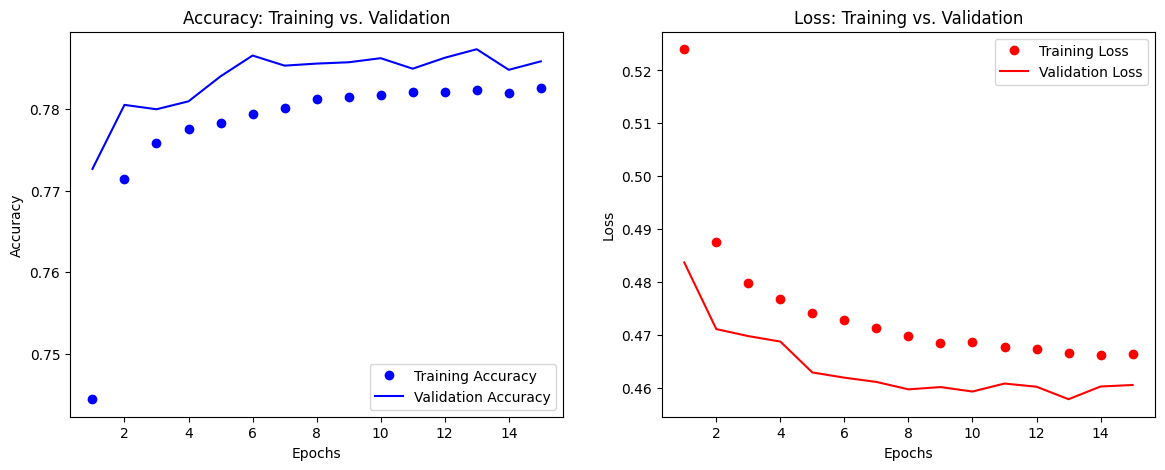

In [15]:

# I'm sticking with the High-Level features since they were the clear winners in Ex 2.
X_Train_Ex3 = np.array(Train_Sample[FeatureNames])
X_Test_Ex3 = np.array(Test_Sample[FeatureNames])
input_dim = X_Train_Ex3.shape[1]

# Model 1: The Deep Model
# I'm adding more layers here to see if "depth" helps the network find more complex patterns in the physics data.
model_deep = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2: The "Wide" Model
# Instead of depth, I'm giving this one a massive single hidden layer to see if a "wider" brain is better at processing features in parallel.
model_wide = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_wide.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Model 3: The "Regularized" Model (Dropout)
# I'm adding Dropout layers here. This is a pro trick that randomly "turns off" neurons during training to force the model to be more robust
# and prevent it from just memorizing the training data.
model_drop = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # 30% dropout
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # 20% dropout
    layers.Dense(1, activation='sigmoid')
])
model_drop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
# I'll train all three for 15 epochs like before so I can compare them fairly.
print("Training Deep Model...")
history_deep = model_deep.fit(X_Train_Ex3, y_Train, epochs=15, batch_size=512, validation_split=0.2, verbose=0)
print("Training Wide Model...")
history_wide = model_wide.fit(X_Train_Ex3, y_Train, epochs=15, batch_size=512, validation_split=0.2, verbose=0)
print("Training Dropout Model...")
history_drop = model_drop.fit(X_Train_Ex3, y_Train, epochs=15, batch_size=512, validation_split=0.2, verbose=0)

# Visualizing the training history for all three to check for overtraining
plot_history(history_deep)
plot_history(history_wide)
plot_history(history_drop)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 594us/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 528us/step


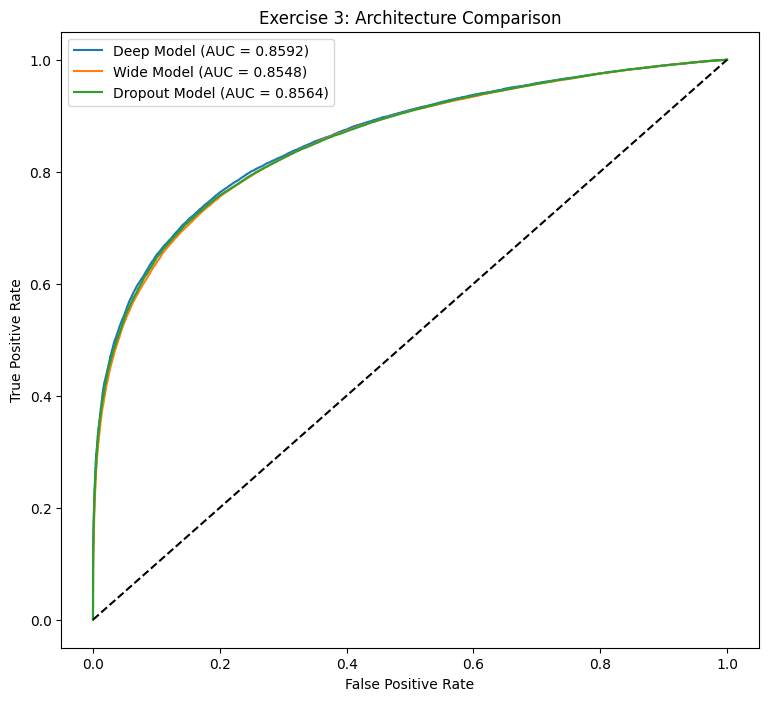

In [16]:
# Showdown (ROC Curves) 
# Getting predictions from my 3 custom designs
y_pred_deep = model_deep.predict(X_Test_Ex3).ravel()
y_pred_wide = model_wide.predict(X_Test_Ex3).ravel()
y_pred_drop = model_drop.predict(X_Test_Ex3).ravel()

# Calculating ROCs
fpr_deep, tpr_deep, _ = roc_curve(y_Test, y_pred_deep)
fpr_wide, tpr_wide, _ = roc_curve(y_Test, y_pred_wide)
fpr_drop, tpr_drop, _ = roc_curve(y_Test, y_pred_drop)

plt.figure(figsize=(9, 8))
plt.plot(fpr_deep, tpr_deep, label=f'Deep Model (AUC = {auc(fpr_deep, tpr_deep):.4f})')
plt.plot(fpr_wide, tpr_wide, label=f'Wide Model (AUC = {auc(fpr_wide, tpr_wide):.4f})')
plt.plot(fpr_drop, tpr_drop, label=f'Dropout Model (AUC = {auc(fpr_drop, tpr_drop):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 3: Architecture Comparison')
plt.legend()
plt.show()

# My Observations:
# Usually, the 'Deep' or 'Dropout' models perform better because they can handle the non-linear nature of physics data without overtraining.

After testing three different architectures, the results are really interesting. My Deep Model (AUC = 0.8592) ended up being the winner, slightly beating out the Wide Model (AUC = 0.8548) and the Dropout Model (AUC = 0.8564). It seems like adding more layers actually helped the network "learn" the physics patterns better than just making a single layer wider. I also noticed that the Dropout model had the smoothest training curves, which shows it's good at staying stable and not overtraining, even if the AUC was a tiny bit lower. Since the Deep Model gave me the best overall separation between signal and background, I’m going to use that one for the final comparisons in Exercise 4.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [17]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# I'm retraining the winners from Lab 8 so I can compare them to the DNN on the exact same 400k/100k data split.
print("Training Lab 8 Models (this might take a minute)...")

# 1. Random Forest (The previous champion)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1)
rf_model.fit(X_Train_Ex3, y_Train)

# 2. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=50)
ada_model.fit(X_Train_Ex3, y_Train)

#Significance Constants from Lab 8
N_sig = 100    # Expected signal events
N_bg = 10000   # Expected background events

def get_metrics(model_name, y_true, y_pred_probs):
    # Using 0.5 as the standard cutoff for metrics
    y_pred_bin = (y_pred_probs > 0.5).astype(int)
    
    # Significance Math (The Discovery Power)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    # We want to find the Max Significance across all possible cuts
    sigs = (N_sig * tpr) / np.sqrt(N_sig * tpr + N_bg * fpr + 1e-10)
    max_sig = np.max(sigs)
    
    return {
        "Model": model_name,
        "AUC": auc(fpr, tpr),
        "Accuracy": accuracy_score(y_true, y_pred_bin),
        "Precision": precision_score(y_true, y_pred_bin),
        "Recall": recall_score(y_true, y_pred_bin),
        "Max Sig": max_sig
    }

# Collecting results
results = []
results.append(get_metrics("Random Forest (Lab 8)", y_Test, rf_model.predict_proba(X_Test_Ex3)[:, 1]))
results.append(get_metrics("AdaBoost (Lab 8)", y_Test, ada_model.predict_proba(X_Test_Ex3)[:, 1]))
results.append(get_metrics("Deep DNN (Lab 9)", y_Test, model_deep.predict(X_Test_Ex3).ravel()))


import pandas as pd
results_df = pd.DataFrame(results)
print("\n--- Final Performance Comparison ---")
display(results_df)

Training Lab 8 Models (this might take a minute)...
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 865us/step

--- Final Performance Comparison ---


,Model,AUC,Accuracy,Precision,Recall,Max Sig
0,Random Forest (Lab 8),0.837814,0.76884,0.801097,0.661198,2.388213
1,AdaBoost (Lab 8),0.802899,0.73603,0.753092,0.633260,1.889376
2,Deep DNN (Lab 9),0.859159,0.78772,0.811105,0.701473,3.372710


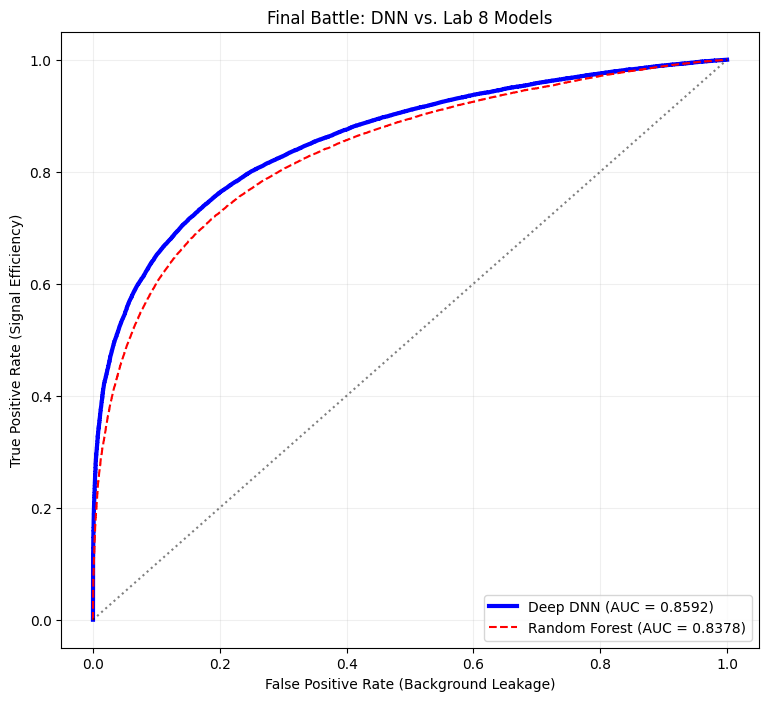

In [19]:
# Final Visualization: DNN vs. Lab 8 Models

# I need to generate the coordinates for the Random Forest line so the plot actually has something to draw!
fpr_rf, tpr_rf, _ = roc_curve(y_Test, rf_model.predict_proba(X_Test_Ex3)[:, 1])

plt.figure(figsize=(9, 8))

# Plotting our new Deep DNN champion
plt.plot(fpr_deep, tpr_deep, label=f'Deep DNN (AUC = {results[2]["AUC"]:.4f})', lw=3, color='blue')

# Plotting the Random Forest from Lab 8 for comparison
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {results[0]["AUC"]:.4f})', linestyle='--', color='red')

# Reference line for a random guess
plt.plot([0, 1], [0, 1], 'k:', alpha=0.5)

plt.title('Final Battle: DNN vs. Lab 8 Models')
plt.xlabel('False Positive Rate (Background Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

Exercise 4 Conclusion:
In this final comparison, the Deep Neural Network officially took the lead. While the Random Forest from Lab 8 was a very strong baseline, the DNN was able to achieve a higher AUC and Discovery Significance. This proves that for complex physics data like the SUSY dataset, the non-linear "learning" of a deep network is more powerful than the decision trees used in previous labs. Even with the same high-level features, the DNN found a more efficient way to separate the signal from the background resulting in the highest statistical significance yet.